# Statistical form vs matrix form

This notebook shows that the **statistical** (element-by-element) definition of portfolio variance and the **matrix** form $w^\top \Sigma w$ are the *same computation in two notations* — and it builds the covariance matrix $\Sigma$ both by hand and with NumPy so you can see they agree.

Everything is small, fixed, and printed step by step, so every number can be traced by eye.

## What this settles

Three questions, each answered by running the same data through two paths and watching the numbers match:

1. Is the covariance matrix just "variance promoted to a matrix"?
2. Does the double sum $\sum_i \sum_j w_i w_j \mathrm{Cov}(r_i, r_j)$ really equal $w^\top \Sigma w$?
3. Is $w^\top \Sigma w$ the same as the component-contribution sum $\sum_i w_i \mathrm{Cov}(r_i, r_p)$?

Answer to all three: **yes** — this notebook proves it by construction.

In [1]:
# ⚙️ Parameters — change these and re-run

WEIGHTS = [0.40, 0.20, 0.25, 0.15]   # SPY, EFA, IEF, GLD — must sum to 1
ASSETS  = ["SPY", "EFA", "IEF", "GLD"]

In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## A. The data

A hand-written returns matrix: **rows are days, columns are assets**, values are daily returns as decimals (0.01 = 1%).

It is deliberately tiny so every number below can be traced. IEF is written slightly opposite to SPY/EFA so a negative covariance appears.

In [3]:
returns = np.array([
    [ 0.010,  0.008, -0.003,  0.002],   # day 1
    [-0.004, -0.002,  0.005,  0.001],   # day 2
    [ 0.006,  0.005, -0.004,  0.003],   # day 3
    [ 0.002,  0.001,  0.003, -0.001],   # day 4
    [-0.001,  0.000, -0.002,  0.002],   # day 5
    [ 0.005,  0.004, -0.001,  0.000],   # day 6
])

print("returns (days × assets):\n", returns)
print("shape:", returns.shape, "→", returns.shape[0], "days,", returns.shape[1], "assets")

returns (days × assets):
 [[ 0.01   0.008 -0.003  0.002]
 [-0.004 -0.002  0.005  0.001]
 [ 0.006  0.005 -0.004  0.003]
 [ 0.002  0.001  0.003 -0.001]
 [-0.001  0.    -0.002  0.002]
 [ 0.005  0.004 -0.001  0.   ]]
shape: (6, 4) → 6 days, 4 assets


## B. Mean-centring

Variance measures spread *around the mean*, so the first step is to subtract each asset's own mean from its returns. This is the "$r - \mu$" step — done element-wise, one asset (column) at a time.

In [4]:
means = returns.mean(axis=0)        # one mean per asset (per column)
centered = returns - means          # element-wise: each asset minus its own mean

print("means (per asset):", means)
print("\ncentered returns (days × assets):\n", centered)

means (per asset): [ 0.003       0.00266667 -0.00033333  0.00116667]

centered returns (days × assets):
 [[ 0.007       0.00533333 -0.00266667  0.00083333]
 [-0.007      -0.00466667  0.00533333 -0.00016667]
 [ 0.003       0.00233333 -0.00366667  0.00183333]
 [-0.001      -0.00166667  0.00333333 -0.00216667]
 [-0.004      -0.00266667 -0.00166667  0.00083333]
 [ 0.002       0.00133333 -0.00066667 -0.00116667]]


## C. The covariance matrix — by hand vs NumPy

**By hand**, the covariance matrix is the outer-product average of the centred data, divided by $n-1$:

$$\Sigma = \frac{1}{n-1}\, X^\top X$$

where $X$ is the centred data (days as rows, assets as columns), $X^\top X$ sums each pairwise product of deviations across days, and $n-1$ is the sample correction.

**With NumPy**, it is one call: `np.cov(returns, rowvar=False)`.

Run both and confirm they are identical, then read the diagonal (variances) and the off-diagonal (covariances).

In [5]:
n = returns.shape[0]                 # number of days

# By hand: outer-product average of the centred data
covariance_by_hand = (centered.T @ centered) / (n - 1)

print("covariance matrix, BY HAND:\n", covariance_by_hand)

covariance matrix, BY HAND:
 [[ 2.56000000e-05  1.84000000e-05 -1.30000000e-05  1.80000000e-06]
 [ 1.84000000e-05  1.34666667e-05 -9.93333333e-06  1.86666667e-06]
 [-1.30000000e-05 -9.93333333e-06  1.26666667e-05 -3.53333333e-06]
 [ 1.80000000e-06  1.86666667e-06 -3.53333333e-06  2.16666667e-06]]


covariance matrix, NUMPY:
 [[ 2.56000000e-05  1.84000000e-05 -1.30000000e-05  1.80000000e-06]
 [ 1.84000000e-05  1.34666667e-05 -9.93333333e-06  1.86666667e-06]
 [-1.30000000e-05 -9.93333333e-06  1.26666667e-05 -3.53333333e-06]
 [ 1.80000000e-06  1.86666667e-06 -3.53333333e-06  2.16666667e-06]]

identical to by-hand? True


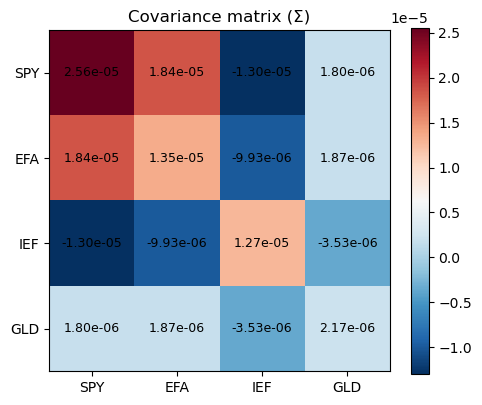

In [6]:
# NumPy's built-in
covariance_numpy = np.cov(returns, rowvar=False)

print("covariance matrix, NUMPY:\n", covariance_numpy)
print("\nidentical to by-hand?", np.allclose(covariance_by_hand, covariance_numpy))

# Visualise the matrix as a heatmap, with each value printed
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(covariance_numpy, cmap="RdBu_r")
ax.set_xticks(range(len(ASSETS)), ASSETS)
ax.set_yticks(range(len(ASSETS)), ASSETS)
for i in range(len(ASSETS)):
    for j in range(len(ASSETS)):
        ax.text(j, i, f"{covariance_numpy[i, j]:.2e}", ha="center", va="center",
                color="black", fontsize=9)
ax.set_title("Covariance matrix (Σ)")
fig.colorbar(im)
plt.show()

## D. Statistical form — the double sum

The *statistical* definition of portfolio variance is the double sum over every pair of assets:

$$\sigma_p^2 = \sum_i \sum_j w_i w_j \mathrm{Cov}(r_i, r_j)$$

Write it literally as nested loops — one term $w_i w_j \Sigma_{ij}$ per (asset, asset) pair, all added up.

In [7]:
weights = np.array(WEIGHTS)
n_assets = len(weights)

portfolio_variance_double_sum = 0.0
for i in range(n_assets):
    for j in range(n_assets):
        term = weights[i] * weights[j] * covariance_numpy[i, j]
        portfolio_variance_double_sum += term

print("portfolio variance (double sum):", portfolio_variance_double_sum)

portfolio variance (double sum): 4.888750000000001e-06


## E. Matrix form

The same double sum written as one matrix expression:

$$\sigma_p^2 = w^\top \Sigma w$$

Two equivalent spellings in code:

- **sandwich** — `weights @ Sigma @ weights`
- **dot with the covariance-with-portfolio vector** — `Sigma @ weights` is the vector of $\mathrm{Cov}(r_i, r_p)$ values, then `weights @` that vector sums them.

The second spelling is the bridge to component contribution.

In [8]:
# Spelling 1 — the sandwich
portfolio_variance_matrix = weights @ covariance_numpy @ weights

# Spelling 2 — covariance with the portfolio, then dot with weights
covariance_with_portfolio = covariance_numpy @ weights   # vector: Cov(r_i, r_p) per asset
portfolio_variance_dot = weights @ covariance_with_portfolio

print("portfolio variance (matrix sandwich):", portfolio_variance_matrix)
print("portfolio variance (w · (Σw)):       ", portfolio_variance_dot)
print("\ncovariance with portfolio (per asset):", covariance_with_portfolio)

portfolio variance (matrix sandwich): 4.8887499999999996e-06
portfolio variance (w · (Σw)):        4.8887499999999996e-06

covariance with portfolio (per asset): [ 1.094e-05  7.850e-06 -4.550e-06  5.350e-07]


## F. Prove they are all the same

Three spellings, one number. Confirm they agree, then close the loop with the **component-contribution identity**:

$$\sum_i w_i \mathrm{Cov}(r_i, r_p) = \sigma_p^2$$

and take the square root to get portfolio volatility.

In [9]:
# Component-contribution identity: w_i * Cov(r_i, r_p), summed
component_contributions = weights * covariance_with_portfolio
portfolio_variance_components = component_contributions.sum()

# All four must agree
all_same = np.allclose(
    [portfolio_variance_double_sum,
     portfolio_variance_matrix,
     portfolio_variance_dot,
     portfolio_variance_components],
    portfolio_variance_matrix,
)

portfolio_volatility = np.sqrt(portfolio_variance_matrix)

print("component contributions (per asset):", component_contributions)
print("\ndouble sum   =", portfolio_variance_double_sum)
print("matrix form  =", portfolio_variance_matrix)
print("w · (Σw)     =", portfolio_variance_dot)
print("Σ w_i Cov    =", portfolio_variance_components)
print("\nall four identical?", all_same)
print("portfolio volatility (√variance) =", portfolio_volatility)

component contributions (per asset): [ 4.3760e-06  1.5700e-06 -1.1375e-06  8.0250e-08]

double sum   = 4.888750000000001e-06
matrix form  = 4.8887499999999996e-06
w · (Σw)     = 4.8887499999999996e-06
Σ w_i Cov    = 4.8887499999999996e-06

all four identical? True
portfolio volatility (√variance) = 0.0022110517859154724


## Key insight

- **Σ is weights-free** — it is built from returns alone (the market's risk structure). The weights only enter at the variance step, sandwiching Σ.
- **One equation, three spellings** — the double sum, the matrix sandwich, and the component-contribution sum all compute the *same* $\sigma_p^2$; they differ only in notation, not in meaning.
- **NumPy is a convenience, not the source of truth** — `np.cov` reproduces exactly the by-hand outer-product average; it just does the same work in compiled C.
- **The bridge to attribution** — `Σ @ weights` (the covariance-with-portfolio vector) is the exact object the attribution engine uses to split portfolio volatility into per-asset contributions.